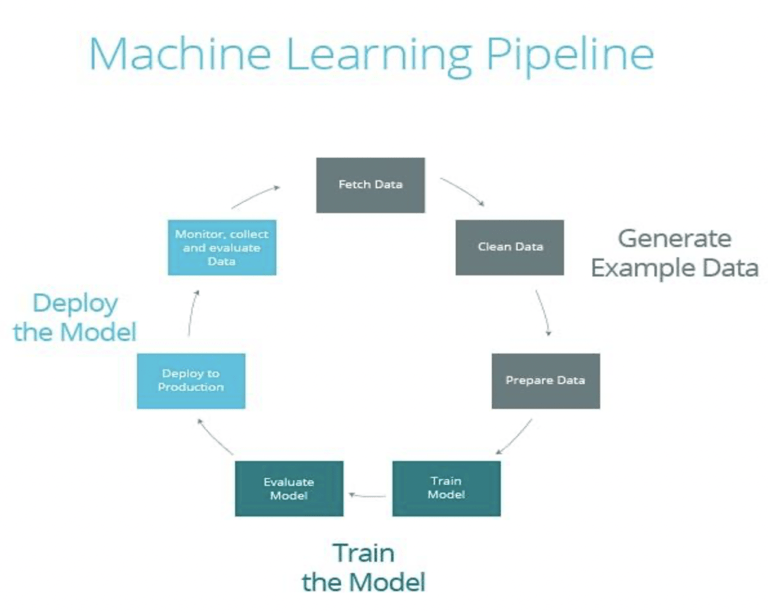

## ➿ Machine learning loop

### 🎒 Packages

In [38]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
pd.set_option('display.max_colwidth', None)
import random

---

### 🚙 Utilities

In [3]:
train_path = Path("..") / "data" / "train.csv"
# only used for final outputing (estimation on real data)
test_path = Path("..") / "data" / "test.csv"
# store
store_path = Path("..") / "data" / "store.csv"

In [4]:
pastel_colors = sns.color_palette("pastel")

def color():
    color = random.choice(pastel_colors)
    return color

---

### 📊 Data + Simple preprocessing to fill NA

#### 🫦 Problem of mixed types ✅

In [5]:
train = pd.read_csv(
    train_path,
    parse_dates=["Date"],
    dtype={"StateHoliday": "str"}
)

In [6]:
train = pd.read_csv(filepath_or_buffer=train_path, parse_dates=["Date"], low_memory=False)
test = pd.read_csv(filepath_or_buffer=test_path, parse_dates=["Date"])
store = pd.read_csv(filepath_or_buffer=store_path)

In [7]:
store.head(5)

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [24]:
store.info()

<class 'pandas.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   str    
 2   Assortment                 1115 non-null   str    
 3   CompetitionDistance        1115 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    str    
dtypes: float64(5), int64(2), str(3)
memory usage: 87.2 KB


#### 🎖️ Fill the NA with median on the competition distance

In [23]:
store["CompetitionDistance"] = store["CompetitionDistance"].fillna(store["CompetitionDistance"].median())

In [8]:
train.head(5)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [47]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   Store          1017209 non-null  int64         
 1   DayOfWeek      1017209 non-null  int64         
 2   Date           1017209 non-null  datetime64[us]
 3   Sales          1017209 non-null  int64         
 4   Customers      1017209 non-null  int64         
 5   Open           1017209 non-null  int64         
 6   Promo          1017209 non-null  int64         
 7   StateHoliday   1017209 non-null  str           
 8   SchoolHoliday  1017209 non-null  int64         
dtypes: datetime64[us](1), int64(7), str(1)
memory usage: 69.8 MB


In [9]:
train["StateHoliday"].describe()

count     1017209
unique          4
top             0
freq       986159
Name: StateHoliday, dtype: object

In [10]:
test.head(5)

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0


---

### 🥼 Feature engineerings

##### 🈂️ Merge train and store, each record = sale on that day and the store's information

In [32]:
df = train.merge(store, on="Store", how="left")

In [33]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


##### 🦢 Date features

In [34]:
# convert Date into Dates (for processing)
df["Date"] = pd.to_datetime(df["Date"])

df["year"] = df["Date"].dt.year
df["month"] = df["Date"].dt.month
df["day"] = df["Date"].dt.day
df["weekofyear"] = df["Date"].dt.isocalendar().week
df["is_weekend"] = df["DayOfWeek"].isin([6,7]).astype(int)

In [35]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,year,month,day,weekofyear,is_weekend
0,1,5,2015-07-31,5263,555,1,1,0,1,c,...,2008.0,0,NaN,NaN,NaN,2015,7,31,31,0
1,2,5,2015-07-31,6064,625,1,1,0,1,a,...,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,31,0
2,3,5,2015-07-31,8314,821,1,1,0,1,a,...,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,31,0
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,...,2009.0,0,NaN,NaN,NaN,2015,7,31,31,0
4,5,5,2015-07-31,4822,559,1,1,0,1,a,...,2015.0,0,NaN,NaN,NaN,2015,7,31,31,0


#### 🔩 Competition duration

In [36]:
# calculate the number of months that the competition store has opened
df["CompetitionOpenSince"] = (
    (df["year"] - df["CompetitionOpenSinceYear"]) * 12 +
    (df["month"] - df["CompetitionOpenSinceMonth"])
)
df["CompetitionOpenSince"] = df["CompetitionOpenSince"].clip(lower=0)

In [39]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,year,month,day,weekofyear,is_weekend,CompetitionOpenSince
0,1,5,2015-07-31,5263,555,1,1,0,1,c,...,0,NaN,NaN,NaN,2015,7,31,31,0,82.0
1,2,5,2015-07-31,6064,625,1,1,0,1,a,...,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,31,0,92.0
2,3,5,2015-07-31,8314,821,1,1,0,1,a,...,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,31,0,103.0
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,...,0,NaN,NaN,NaN,2015,7,31,31,0,70.0
4,5,5,2015-07-31,4822,559,1,1,0,1,a,...,0,NaN,NaN,NaN,2015,7,31,31,0,3.0


#### 🧾 Promo2 (long-term impact)

In [40]:
# Calculate the number of weeks that the promo2 has been applied
df["Promo2Since"] = (
    (df["year"] - df["Promo2SinceYear"]) * 52 +
    (df["weekofyear"] - df["Promo2SinceWeek"])
)
df["Promo2Since"] = df["Promo2Since"].clip(lower=0)

In [42]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,Promo2SinceWeek,Promo2SinceYear,PromoInterval,year,month,day,weekofyear,is_weekend,CompetitionOpenSince,Promo2Since
0,1,5,2015-07-31,5263,555,1,1,0,1,c,...,NaN,NaN,NaN,2015,7,31,31,0,82.0,<NA>
1,2,5,2015-07-31,6064,625,1,1,0,1,a,...,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,31,0,92.0,278.0
2,3,5,2015-07-31,8314,821,1,1,0,1,a,...,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,31,0,103.0,225.0
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,...,NaN,NaN,NaN,2015,7,31,31,0,70.0,<NA>
4,5,5,2015-07-31,4822,559,1,1,0,1,a,...,NaN,NaN,NaN,2015,7,31,31,0,3.0,<NA>


In [ ]:
month_str = df["Date"].dt.strftime("%b")

# The current day is in the Promo2 or not
df["IsPromoMonth"] = df.apply(
    lambda x: 1 if isinstance(x["PromoInterval"], str) and month_str[x.name] in x["PromoInterval"] else 0,
    axis=1
)

In [44]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,Promo2SinceYear,PromoInterval,year,month,day,weekofyear,is_weekend,CompetitionOpenSince,Promo2Since,IsPromoMonth
0,1,5,2015-07-31,5263,555,1,1,0,1,c,...,NaN,NaN,2015,7,31,31,0,82.0,<NA>,0
1,2,5,2015-07-31,6064,625,1,1,0,1,a,...,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,31,0,92.0,278.0,1
2,3,5,2015-07-31,8314,821,1,1,0,1,a,...,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,31,0,103.0,225.0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,...,NaN,NaN,2015,7,31,31,0,70.0,<NA>,0
4,5,5,2015-07-31,4822,559,1,1,0,1,a,...,NaN,NaN,2015,7,31,31,0,3.0,<NA>,0


#### 🗼 One hot encoding for categorical columns

In [ ]:
# Convert labels into simple labels
for col in ["StoreType", "Assortment", "StateHoliday"]:
    df[col] = df[col].astype("category").cat.codes

In [46]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,Promo2SinceYear,PromoInterval,year,month,day,weekofyear,is_weekend,CompetitionOpenSince,Promo2Since,IsPromoMonth
0,1,5,2015-07-31,5263,555,1,1,0,1,2,...,NaN,NaN,2015,7,31,31,0,82.0,<NA>,0
1,2,5,2015-07-31,6064,625,1,1,0,1,0,...,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,31,0,92.0,278.0,1
2,3,5,2015-07-31,8314,821,1,1,0,1,0,...,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,31,0,103.0,225.0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1,2,...,NaN,NaN,2015,7,31,31,0,70.0,<NA>,0
4,5,5,2015-07-31,4822,559,1,1,0,1,0,...,NaN,NaN,2015,7,31,31,0,3.0,<NA>,0


#### 💫 Closed -> Sales = 0, we want the model to learn the Sales when store is open (pure), we don't want it to learn deterministic rules

In [48]:
df = df[df["Open"] == 1]

#### 🍰 No lag features now, meaning we just use the current information of the store to predict the current Sales

In [ ]:
train_df = df[df["Date"] < "2015-06-01"]
val_df   = df[df["Date"] >= "2015-06-01"]